In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

n = 100

x1 = np.random.randn(n)
x2 = x1 + 0.01 * np.random.randn(n)
X = np.column_stack([x1, x2])
w_true = np.array([2.0, -2.0])
y = X @ w_true + 0.5 * np.random.randn(n)


In [2]:
def ols_loss(w, X, y):
    return np.sum((y - X @ w) ** 2)

def ridge_loss(w, X, y, lam=10.0):
    return np.sum((y - X @ w) ** 2) + lam * np.sum(w ** 2)


In [3]:
w1_vals = np.linspace(-10, 10, 200)
w2_vals = np.linspace(-10, 10, 200)

W1, W2 = np.meshgrid(w1_vals, w2_vals)

Z_ols = np.zeros_like(W1)
Z_ridge = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w = np.array([W1[i, j], W2[i, j]])
        Z_ols[i, j] = ols_loss(w, X, y)
        Z_ridge[i, j] = ridge_loss(w, X, y, lam=10.0)


In [11]:
w1_vals = np.linspace(-10, 10, 150)
w2_vals = np.linspace(-10, 10, 150)

W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w = np.array([W1[i, j], W2[i, j]])
        Z[i, j] = ols_loss(w, X, y)


lam = 10.0  # regularization strength

Z_ridge = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w = np.array([W1[i, j], W2[i, j]])
        Z_ridge[i, j] = np.sum((y - X @ w) ** 2) + lam * np.sum(w ** 2)


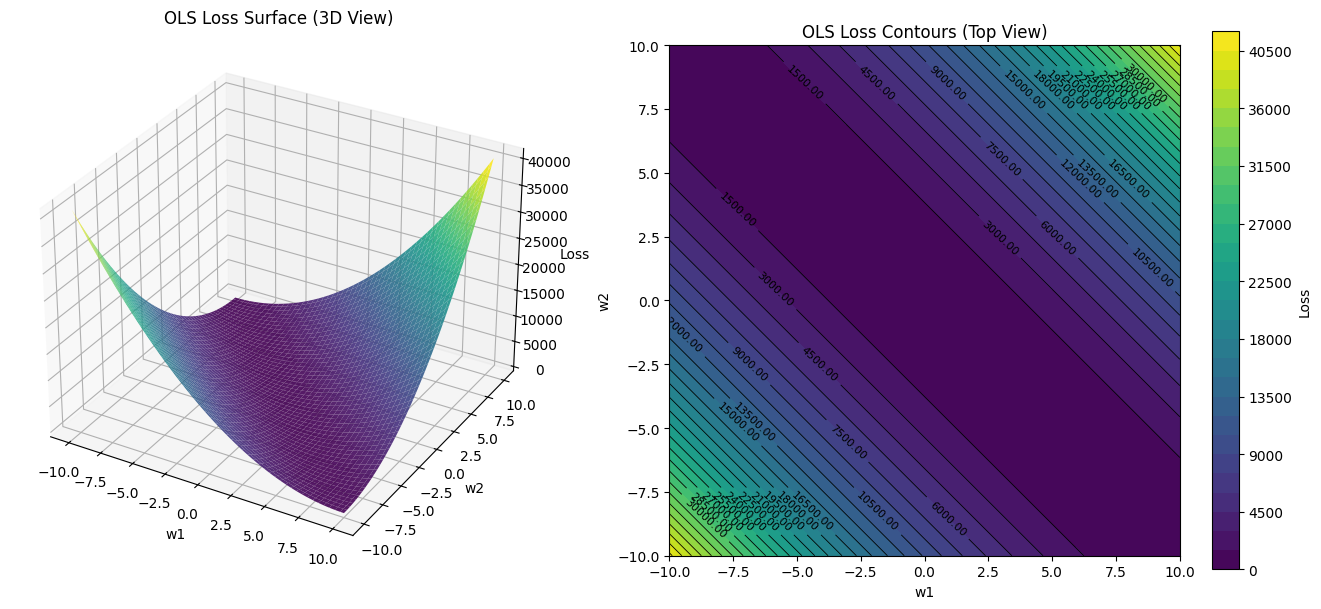

In [12]:
fig = plt.figure(figsize=(14, 6))

# ---------- 3D Surface ----------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.9)
ax1.set_xlabel("w1")
ax1.set_ylabel("w2")
ax1.set_zlabel("Loss")
ax1.set_title("OLS Loss Surface (3D View)")

# ---------- Contour (FILLED + LABELED) ----------
ax2 = fig.add_subplot(1, 2, 2)

# Filled contours (color bands)
cf = ax2.contourf(
    W1, W2, Z,
    levels=30,
    cmap="viridis"
)

# Contour lines on top
cs = ax2.contour(
    W1, W2, Z,
    levels=30,
    colors="black",
    linewidths=0.6
)

# Labels on contour lines
ax2.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

# Colorbar
fig.colorbar(cf, ax=ax2, label="Loss")

ax2.set_xlabel("w1")
ax2.set_ylabel("w2")
ax2.set_title("OLS Loss Contours (Top View)")

# IMPORTANT: keep contours circular / elliptical (not stretched)
ax2.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


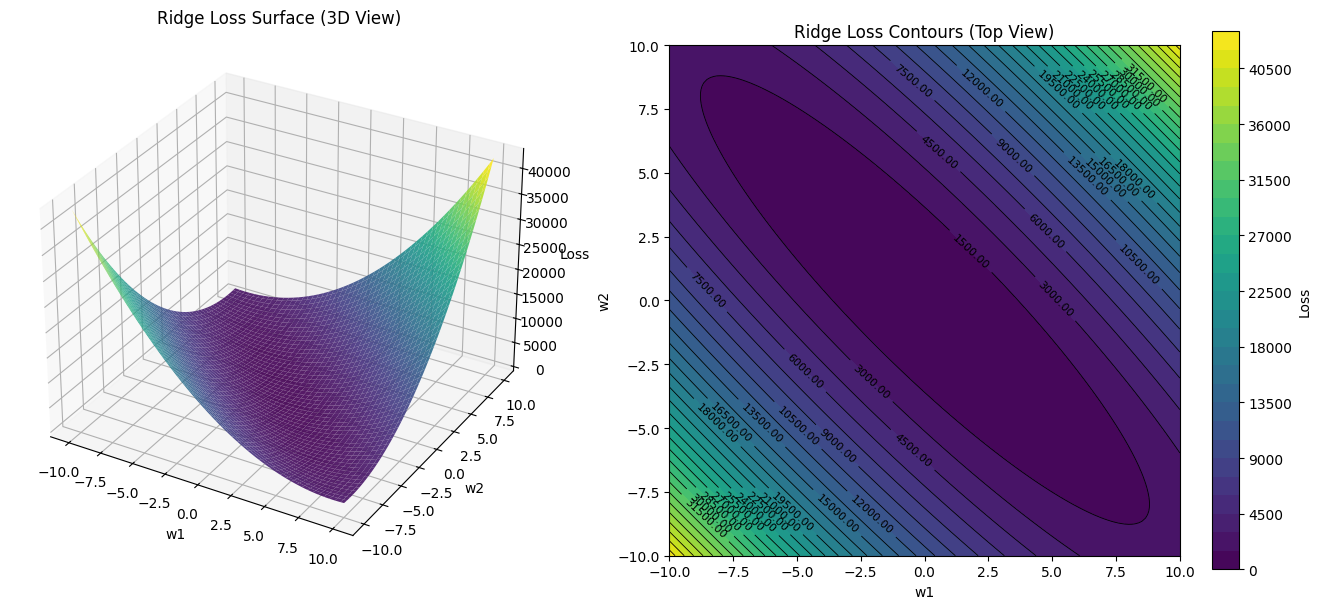

In [ ]:
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(W1, W2, Z_ridge, cmap='viridis', alpha=0.9)
ax1.set_xlabel("w1")
ax1.set_ylabel("w2")
ax1.set_zlabel("Loss")
ax1.set_title("Ridge Loss Surface (3D View)")


ax2 = fig.add_subplot(1, 2, 2)

cf = ax2.contourf(
    W1, W2, Z_ridge,
    levels=30,
    cmap="viridis"
)

cs = ax2.contour(
    W1, W2, Z_ridge,
    levels=30,
    colors="black",
    linewidths=0.6
)

ax2.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

fig.colorbar(cf, ax=ax2, label="Loss")

ax2.set_xlabel("w1")
ax2.set_ylabel("w2")
ax2.set_title("Ridge Loss Contours (Top View)")

# Keep geometry correct
ax2.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()
